In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [340]:
df = pd.read_csv('C:/Users/Pavel/Lessen_jypyter/csv/taxi_trip_pricing.csv')
dataset = df.copy()

In [341]:
dataset

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.35,Morning,Weekday,3.0,Low,Clear,3.56,0.80,0.32,53.82,36.2624
1,47.59,Afternoon,Weekday,1.0,High,Clear,NaN,0.62,0.43,40.57,NaN
2,36.87,Evening,Weekend,1.0,High,Clear,2.70,1.21,0.15,37.27,52.9032
3,30.33,Evening,Weekday,4.0,Low,NaN,3.48,0.51,0.15,116.81,36.4698
4,NaN,Evening,Weekday,3.0,High,Clear,2.93,0.63,0.32,22.64,15.6180
...,...,...,...,...,...,...,...,...,...,...,...
995,5.49,Afternoon,Weekend,4.0,Medium,Clear,2.39,0.62,0.49,58.39,34.4049
996,45.95,Night,Weekday,4.0,Medium,Clear,3.12,0.61,NaN,61.96,62.1295
997,7.70,Morning,Weekday,3.0,Low,Rain,2.08,1.78,NaN,54.18,33.1236
998,47.56,Morning,Weekday,1.0,Low,Clear,2.67,0.82,0.17,114.94,61.2090


In [342]:
isna = dataset.isna().sum()
duplicate = dataset.duplicated().sum()
info = dataset.info()
print('Пропуски :\n', isna)
print("Дубликаты", duplicate)
print("info", info)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Trip_Distance_km       950 non-null    float64
 1   Time_of_Day            950 non-null    object 
 2   Day_of_Week            950 non-null    object 
 3   Passenger_Count        950 non-null    float64
 4   Traffic_Conditions     950 non-null    object 
 5   Weather                950 non-null    object 
 6   Base_Fare              950 non-null    float64
 7   Per_Km_Rate            950 non-null    float64
 8   Per_Minute_Rate        950 non-null    float64
 9   Trip_Duration_Minutes  950 non-null    float64
 10  Trip_Price             951 non-null    float64
dtypes: float64(7), object(4)
memory usage: 86.1+ KB
Пропуски :
 Trip_Distance_km         50
Time_of_Day              50
Day_of_Week              50
Passenger_Count          50
Traffic_Conditions       50
Weather      

In [343]:
dataset.describe()

,Trip_Distance_km,Passenger_Count,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
count,950.000000,950.000000,950.000000,950.000000,950.000000,950.000000,951.000000
mean,27.070547,2.476842,3.502989,1.233316,0.292916,62.118116,56.874773
std,19.905300,1.102249,0.870162,0.429816,0.115592,32.154406,40.469791
min,1.230000,1.000000,2.010000,0.500000,0.100000,5.010000,6.126900
25%,12.632500,1.250000,2.730000,0.860000,0.190000,35.882500,33.742650
50%,25.830000,2.000000,3.520000,1.220000,0.290000,61.860000,50.074500
75%,38.405000,3.000000,4.260000,1.610000,0.390000,89.055000,69.099350
max,146.067047,4.000000,5.000000,2.000000,0.500000,119.840000,332.043689


In [344]:
dataset.columns
# weekday будние, weekend выходные

Index(['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price'],
      dtype='object')

In [345]:
mean_columns = ['Trip_Distance_km', 'Passenger_Count', 'Base_Fare', 'Per_Km_Rate',
                'Trip_Duration_Minutes', 'Per_Minute_Rate',]
label_columns = ['Time_of_Day', 'Day_of_Week', 'Traffic_Conditions', 'Weather']
encoder_columns =['Trip_Distance_km', 'Time_of_Day', 'Day_of_Week', 'Passenger_Count',
       'Traffic_Conditions', 'Weather', 'Base_Fare', 'Per_Km_Rate',
       'Per_Minute_Rate', 'Trip_Duration_Minutes', 'Trip_Price']


In [346]:
dataset['Time_of_Day'] = dataset['Time_of_Day'].map({'Afternoon': 0,'Morning': 1, 'Evening': 2, 'Night': 3}).astype(float)
dataset['Day_of_Week'] = dataset['Day_of_Week'].map({'Weekday': 0, 'Weekend': 1}).astype(float)
dataset['Traffic_Conditions'] = dataset['Traffic_Conditions'].map({'Low': 0, 'Medium': 1, 'High': 2}).astype(float)
dataset['Weather'] = dataset['Weather'].map({'Clear': 0, 'Rain': 1, 'Snow': 2}).astype(float)

In [347]:
for mean in mean_columns:
    dataset[mean] = dataset[mean].fillna(dataset[columns].mean())

In [348]:
dataset['Weather'].value_counts()

Weather
0.0    667
1.0    227
2.0     56
Name: count, dtype: int64

In [349]:
for columns in label_columns:
    dataset[columns] = dataset[columns].fillna(dataset[columns].mean())

In [350]:
q1 = dataset[['Trip_Distance_km', 'Trip_Price', 'Per_Km_Rate']].quantile(0.25)
q2 = dataset[['Trip_Distance_km', 'Trip_Price', 'Per_Km_Rate']].quantile(0.50)
q3 = dataset[['Trip_Distance_km', 'Trip_Price', 'Per_Km_Rate']].quantile(0.75)
q_min = dataset[['Trip_Distance_km', 'Trip_Price', 'Per_Km_Rate']].min()
q_max = dataset[['Trip_Distance_km', 'Trip_Price', 'Per_Km_Rate']].max()
q1_km= q1.iloc[0]
q1_price = q1.iloc[1]
q1_km_rate = q1.iloc[2]
q2_km= q2.iloc[0]
q2_price = q2.iloc[1]
q2_km_rate = q2.iloc[2]
q3_km= q3.iloc[0]
q3_price = q3.iloc[1]
q3_km_rate = q3.iloc[2]
q_min_price = q_min.iloc[1]
q_max_km = q_max.iloc[0]
q_max_price = q_max.iloc[1]
q_max_km_rate = q_max.iloc[2]

In [351]:
# цена
for row, value in dataset['Trip_Price'].items():
    if pd.isna(value):
        km = df.loc[row, 'Trip_Distance_km']
        km_rate = df.loc[row, 'Per_Km_Rate']
        if km < q1_km and km_rate < q1_km_rate:
            dataset.loc[row, 'Trip_Price'] = q1_price
        elif km < q2_km and km_rate < q2_km_rate:
            dataset.loc[row, 'Trip_Price'] = q2_price
        elif km < q3_km and km_rate < q3_km_rate:
            dataset.loc[row, 'Trip_Price'] = q3_price
        elif km < q_max_km and km_rate < q_max_km_rate:
            dataset.loc[row, 'Trip_Price'] = q_max_km / q_max_km_rate
        else:
            dataset.loc[row, 'Trip_Price'] = (q_max_km + q3_km) / q_max_km_rate

In [352]:
dataset

,Trip_Distance_km,Time_of_Day,Day_of_Week,Passenger_Count,Traffic_Conditions,Weather,Base_Fare,Per_Km_Rate,Per_Minute_Rate,Trip_Duration_Minutes,Trip_Price
0,19.350000,1.0,0.0,3.0,0.0,0.000000,3.560000,0.800000,0.320000,53.82,36.262400
1,47.590000,0.0,0.0,1.0,2.0,0.000000,0.356842,0.620000,0.430000,40.57,73.033524
2,36.870000,2.0,1.0,1.0,2.0,0.000000,2.700000,1.210000,0.150000,37.27,52.903200
3,30.330000,2.0,0.0,4.0,0.0,0.356842,3.480000,0.510000,0.150000,116.81,36.469800
4,0.356842,2.0,0.0,3.0,2.0,0.000000,2.930000,0.630000,0.320000,22.64,15.618000
...,...,...,...,...,...,...,...,...,...,...,...
995,5.490000,0.0,1.0,4.0,1.0,0.000000,2.390000,0.620000,0.490000,58.39,34.404900
996,45.950000,3.0,0.0,4.0,1.0,0.000000,3.120000,0.610000,0.356842,61.96,62.129500
997,7.700000,1.0,0.0,3.0,0.0,1.000000,2.080000,1.780000,0.356842,54.18,33.123600
998,47.560000,1.0,0.0,1.0,0.0,0.000000,2.670000,0.820000,0.170000,114.94,61.209000


In [353]:
dataset.isna().sum()
 

Trip_Distance_km         0
Time_of_Day              0
Day_of_Week              0
Passenger_Count          0
Traffic_Conditions       0
Weather                  0
Base_Fare                0
Per_Km_Rate              0
Per_Minute_Rate          0
Trip_Duration_Minutes    0
Trip_Price               0
dtype: int64

<Figure size 900x900 with 0 Axes>

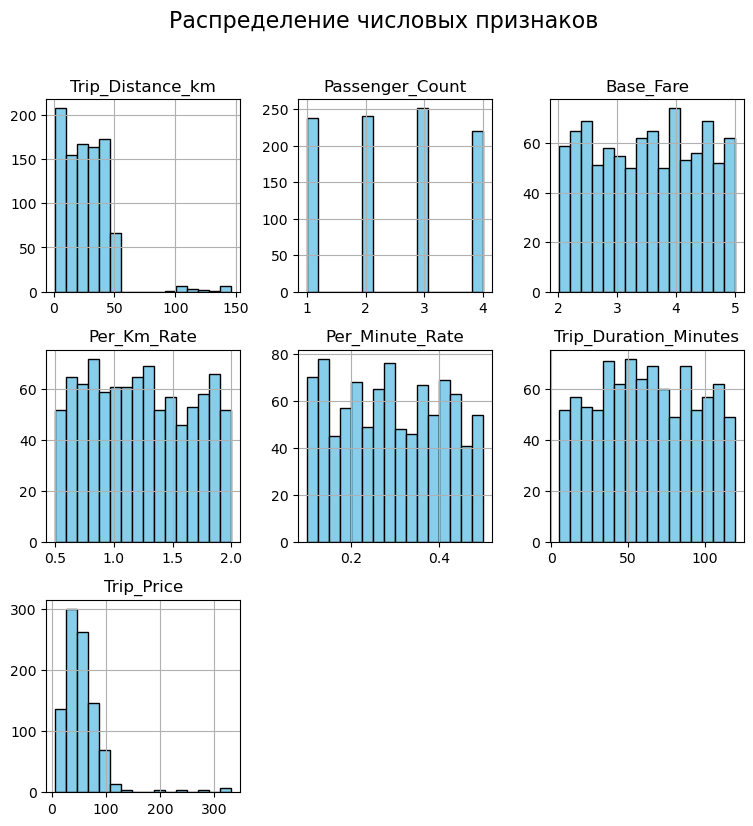

In [354]:
plt.figure(figsize=(9, 9))
df.hist(bins=16, figsize=(9, 9), color='skyblue', edgecolor='black')
plt.suptitle("Распределение числовых признаков", fontsize=16)
plt.show()

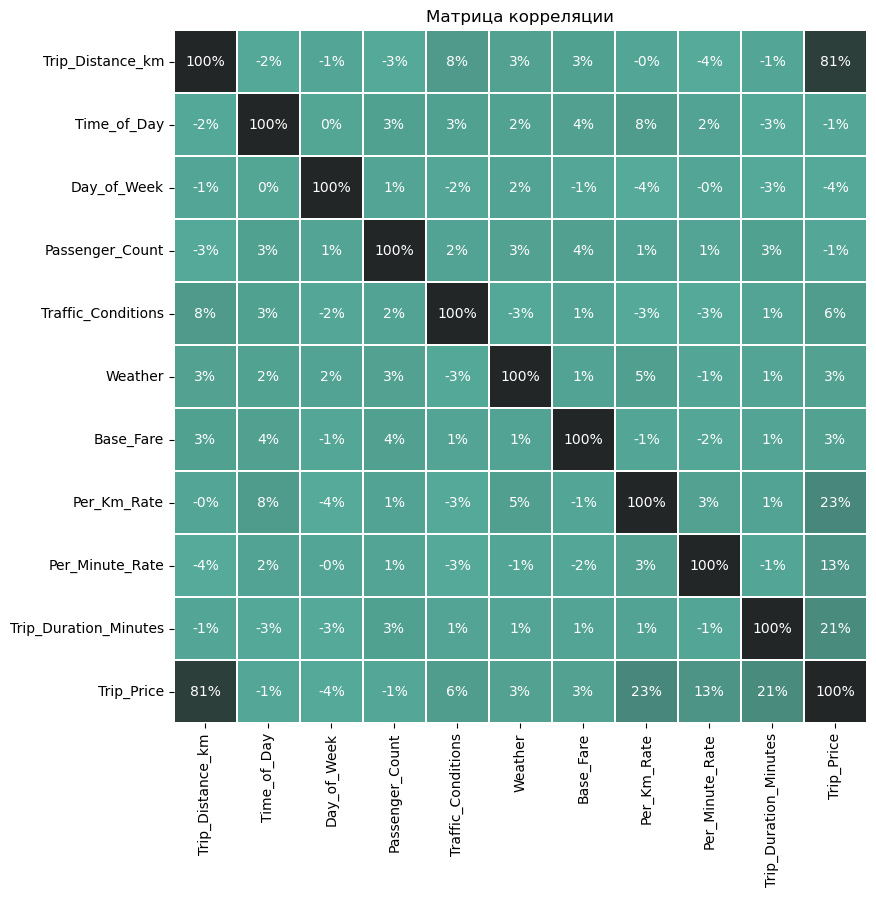

In [355]:
plt.figure(figsize = (9,9))
sns.heatmap(dataset.corr(),
            xticklabels = dataset.corr().columns,
            yticklabels = dataset.corr().columns,
            annot = True,
            fmt = '.0%',
            square = True,
            linewidth = 0.1,
            cmap = sns.color_palette("dark:#5A9_r", as_cmap=True),
            cbar = False
)
plt.title('Матрица корреляции')
plt.show()

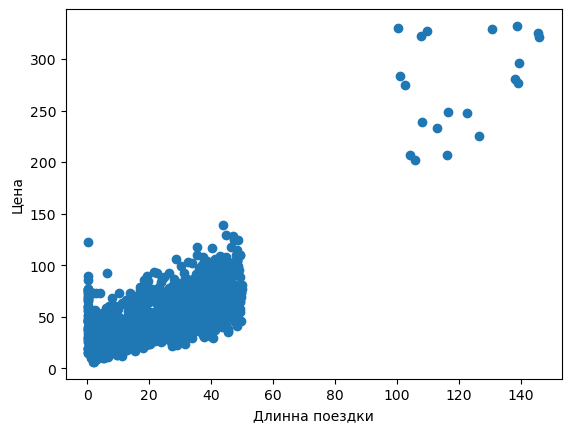

In [369]:
plt.scatter(x=dataset['Trip_Distance_km'],y = dataset['Trip_Price'])
plt.xlabel('Длинна поездки')
plt.ylabel('Цена')
plt.show()

In [437]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

In [407]:
from sklearn import tree
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

In [415]:
from catboost import CatBoostRegressor
import lightgbm as lgb
import xgboost as xgb
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

In [358]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [370]:
X = dataset.drop(columns = ['Trip_Price'], axis = 1)
y = dataset['Trip_Price']

In [375]:
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state = 42, test_size = 0.2)

In [448]:
linear = LinearRegression().fit(X_train, y_train)
linear_predict = linear.predict(X_test)
linear_mae = mean_absolute_error(y_test,linear_predict)
linear_mse = mean_squared_error(y_test, linear_predict)
list_mse.append(linear_mse)
list_mae.append(linear_mae)
list_name.append('linear')

In [449]:
lasso = Lasso(alpha=0.1).fit(X_train, y_train)
lasso_predict = lasso.predict(X_test)
lasso_mae = mean_absolute_error(y_test, lasso_predict)
lasso_mse = mean_squared_error(y_test, lasso_predict)
list_mse.append(lasso_mse)
list_mae.append(lasso_mae)
list_name.append('lasso')

In [450]:
ridge = Ridge(alpha=1).fit(X_train,y_train)
ridge_predict = ridge.predict(X_test)
ridge_mae = mean_absolute_error(y_test,ridge_predict)
ridge_mse =  mean_squared_error(y_test, ridge_predict)
list_mse.append(ridge_mse)
list_mae.append(ridge_mae)
list_name.append('ridge')

In [451]:
tree = DecisionTreeRegressor( max_depth=6,
                             random_state=42
                            )
tree.fit(X_train, y_train)
tree_predict = tree.predict(X_test)
tree_mae = mean_absolute_error(y_test, tree_predict)
tree_mse = mean_squared_error(y_test, tree_predict)
list_mse.append(tree_mse)
list_mae.append(tree_mae)
list_name.append('tree')

In [452]:
random_forest = RandomForestRegressor(n_estimators=100,
                                      max_depth=6,
                                      random_state=42
                                     )
random_forest.fit(X_train, y_train)
random_forest_predict = random_forest.predict(X_test)
random_forest_mae = mean_absolute_error(y_test, random_forest_predict)
random_forest_mse = mean_squared_error(y_test, random_forest_predict)
list_mse.append(random_forest_mse)
list_mae.append(random_forest_mae)
list_name.append('random_forest')

In [417]:
catboost = CatBoostRegressor(n_estimators=100,
                             learning_rate=0.1,
                             max_depth=6,
                             random_state=42,
                             verbose=False
                            )
catboost.fit(X_train, y_train)
catboost_predict = catboost.predict(X_test)

In [453]:
catboost_mae = mean_absolute_error(y_test, catboost_predict)
catboost_mse = mean_squared_error(y_test, catboost_predict)
list_mse.append(catboost_mse)
list_mae.append(catboost_mae)
list_name.append('catboost')

In [454]:
lightgbm_model = LGBMRegressor(n_estimators=100,
                               learning_rate=0.1,
                               max_depth=6,
                               random_state=42
                              )
lightgbm_model.fit(X_train, y_train)
lightgbm_model_predict = lightgbm_model.predict(X_test)
lightgbm_model_mae = mean_absolute_error(y_test, lightgbm_model_predict)
lightgbm_model_mse = mean_squared_error(y_test, lightgbm_model_predict)
list_mse.append(lightgbm_model_mse)
list_mae.append(lightgbm_model_mae)
list_name.append('lightgbm_model')

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000130 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 938
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 10
[LightGBM] [Info] Start training from score 58.169287
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -

In [455]:
xgb_model = XGBRegressor(n_estimators=100,
                         learning_rate=0.1,
                         max_depth=6,
                         random_state=42
                        )
xgb_model.fit(X_train, y_train)
xgb_model_predict = xgb_model.predict(X_test)
xgb_model_mae = mean_absolute_error(y_test, xgb_model_predict)
xgb_model_mse = mean_squared_error(y_test, xgb_model_predict)
list_mse.append(xgb_model_mse)
list_mae.append(xgb_model_mae)
list_name.append('xgb_model')

In [ ]:
model = keras.Sequential([
    layers.Dense(128, activation='relu', input_shape = (10,)),
    layers.Dropout(0.2),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.2),
    layers.Dense(32, activation='relu'),
    layers.Dense(1) 

In [441]:
model = keras.Sequential([
    keras.layers.Flatten(input_shape = (10,)),
    keras.layers.Dense(128,activation = 'relu'),
    keras.layers.Dense(1)
])
model.compile(optimizer='adam',
              loss='mae',
              metrics=['mse'])

C:\Users\Pavel\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [ ]:
model.fit(X_train, y_train, epochs= 200)

In [457]:
test_loss_2, test_acc_2 = model.evaluate(X_train ,y_train, verbose=2)
print('\mse:', test_acc_2)
list_mse.append(test_acc_2)
list_mae.append(test_loss_2)
list_name.append('model_tensofrlow')

25/25 - 0s - 3ms/step - loss: 7.6968 - mse: 190.1183
\mse: 190.11825561523438


In [445]:
list_mse = []
list_mae = []
list_name = []

In [486]:
list_mse.sort()
list_mae.sort()

In [487]:
for model_name, mse_score in zip(list_name, list_mse):
    print(model_name,':', mse_score)

linear : 61.743072146293905
lasso : 66.4659260757969
ridge : 85.85780530276115
tree : 109.65942053083423
random_forest : 161.837366973398
catboost : 190.11825561523438
lightgbm_model : 218.43878298847005
xgb_model : 220.58998549577956
model_tensofrlow : 221.93917324909955


In [488]:
for model_name, mae_score in zip(list_name, list_mae):
    print(model_name,':', mae_score)

linear : 5.286974472413294
lasso : 5.425815394460775
ridge : 5.87713211346783
tree : 7.696765899658203
random_forest : 8.21651392583711
catboost : 9.977189542757628
lightgbm_model : 10.669478286450769
xgb_model : 10.669478286450769
model_tensofrlow : 10.669478286450769
